In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, average_precision_score, ConfusionMatrixDisplay)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [150]:
df = pd.read_csv('data/cleaned_data.csv')
df.rename(columns={'Attrition': 'target'}, inplace=True)
df

,Age,target,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [151]:
# Ставки Daily/Hourly/Monthly это шум в данных, ведь они повторяют информацию в признаке MonthlyIncome

cols_to_drop = ['DailyRate', 'HourlyRate', 'MonthlyRate']
df = df.drop(cols_to_drop, axis=1)
df.shape

(1470, 28)

In [152]:
# Новые признаки 

# Молодой сотрудник
df['IsYoung'] = (df['Age'] < 30).astype(int)

# Высокий риск: сверхурочная работа + низкая удовлетворенность
df['HighRisk'] = ((df['OverTime'] == 'Yes') & (df['JobSatisfaction'] <= 2)).astype(int)

# Сколько сменил компаний относительно стажа 
df['JobHopping'] = (df['NumCompaniesWorked'] / (df['TotalWorkingYears'] + 1)).round().astype(int)

# Низкий баланс жизни и работы
df['BadWorkLife'] = (df['WorkLifeBalance'] == 1).astype(int)

# Большая дистанция от дома
df['FarFromHome'] = (df['DistanceFromHome'] > 10).astype(int)


In [153]:
# Преобразуем целевую переменную
df['target'] = df['target'].map({'Yes': 1, 'No': 0})
df['target'].head()

0    1
1    0
2    1
3    0
4    0
Name: target, dtype: int64

In [154]:
# Диагностика разделения данных: размеры + доля позитивов + первые 3 строки 

def show_datasets(X_train, X_test, Y_train, Y_test):
    
    # DataFrame для обучающей выборки
    train_df = pd.DataFrame(
        data=X_train,
        columns=X_train.columns  
    )
    train_df['y'] = Y_train    

    # DataFrame для тестовой выборки
    test_df = pd.DataFrame(
        data=X_test,
        columns=X_test.columns
    )
    test_df['y'] = Y_test    

    print(f"Размер датасета Train {train_df.shape}")
    print(f"Доля увольнений: {Y_train.mean():.2%}\n")
    display(train_df.head(3))
    
    print(f"Размер датасета Test {test_df.shape}")
    print(f"Доля увольнений: {Y_test.mean():.2%}\n")
    display(test_df.head(3))

In [155]:
# Разделим на X и y
X = df.drop('target', axis=1)
y = df['target']

# Стратифицированное разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [156]:
show_datasets(X_train, X_test, y_train, y_test)

Размер датасета Train (1176, 33)
Доля увольнений: 16.16%



,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IsYoung,HighRisk,JobHopping,BadWorkLife,FarFromHome,y
1194,47,Travel_Rarely,Sales,2,4,Life Sciences,2,Female,4,4,...,3,2,1,2,0,0,0,0,0,0
128,22,Travel_Rarely,Research & Development,2,1,Technical Degree,3,Male,3,1,...,2,1,2,1,1,0,0,0,0,0
810,46,Travel_Rarely,Sales,3,1,Marketing,1,Male,3,4,...,12,9,4,9,0,0,0,0,0,0


Размер датасета Test (294, 33)
Доля увольнений: 15.99%



,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IsYoung,HighRisk,JobHopping,BadWorkLife,FarFromHome,y
1061,24,Non-Travel,Sales,13,2,Life Sciences,4,Female,3,1,...,1,0,0,0,1,0,0,0,1,0
891,44,Travel_Rarely,Research & Development,2,1,Life Sciences,1,Female,4,1,...,10,5,7,7,0,0,0,0,0,0
456,31,Travel_Rarely,Sales,7,3,Life Sciences,3,Male,2,3,...,5,4,0,1,0,0,1,0,0,0


In [158]:
CAT_COLS = X.select_dtypes(include=['str']).columns.tolist()
ORD_COLS = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 
            'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']
NUM_COLS = [col for col in X.select_dtypes(include=['int64', 'float64']).columns if col not in ORD_COLS]

# Контроль: 32 признака = NUM + CAT + ORD, должно сойтись без потерь
print(f"NUM = {len(NUM_COLS)} CAT = {len(CAT_COLS)} ORD = {len(ORD_COLS)} \ntotal = {len(NUM_COLS)+len(CAT_COLS)+len(ORD_COLS)}")

NUM = 16 CAT = 7 ORD = 9 
total = 32


In [ ]:
# Препроцессор:
# - 'num': StandardScaler для NUM_COLS + ORD_COLS (порядковые шкалы 1-5 масштабируем как числа — порядок сохраняется)
# - 'cat': OneHotEncoder(handle_unknown='ignore') для номинальных — новые категории не роняют модель
# - remainder='drop': все лишнее отбрасываем явно, на вход модели идут только описанные колонки
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_COLS + ORD_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
    ],
    remainder='drop'
)

In [ ]:
# Пайплайны: препроцессор + модель в одном Pipeline — fit только на train, transform на test без подглядывания

pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            max_depth=6,
            min_samples_split=10,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_split=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  
            random_state=42,
            eval_metric='logloss',
        ))
    ])
}

In [161]:
results = {}

print("Обучение моделей")

for name, pipe in pipelines.items():
    print(f"\n→ {name}")
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'pipeline': pipe,
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print(f"  F1        : {results[name]['f1']:.4f}")
    print(f"  ROC-AUC   : {results[name]['roc_auc']:.4f}")
    print(f"  PR-AUC    : {results[name]['pr_auc']:.4f}")
    print(f"  Precision : {results[name]['precision']:.4f}")
    print(f"  Recall    : {results[name]['recall']:.4f}")

# Сводная таблица
results_df = pd.DataFrame({
    name: {
        'F1': res['f1'],
        'ROC-AUC': res['roc_auc'],
        'PR-AUC': res['pr_auc'],
        'Precision': res['precision'],
        'Recall': res['recall']
    } for name, res in results.items()
}).T.round(4).sort_values('PR-AUC', ascending=False)

print("СРАВНЕНИЕ МОДЕЛЕЙ\n")
print(results_df)

Обучение моделей

→ Logistic Regression
  F1        : 0.4923
  ROC-AUC   : 0.8150
  PR-AUC    : 0.5931
  Precision : 0.3855
  Recall    : 0.6809

→ Decision Tree
  F1        : 0.4333
  ROC-AUC   : 0.6518
  PR-AUC    : 0.3517
  Precision : 0.3562
  Recall    : 0.5532

→ Random Forest
  F1        : 0.4898
  ROC-AUC   : 0.7878
  PR-AUC    : 0.4455
  Precision : 0.4706
  Recall    : 0.5106

→ XGBoost
  F1        : 0.4359
  ROC-AUC   : 0.8100
  PR-AUC    : 0.5059
  Precision : 0.5484
  Recall    : 0.3617
СРАВНЕНИЕ МОДЕЛЕЙ

                         F1  ROC-AUC  PR-AUC  Precision  Recall
Logistic Regression  0.4923   0.8150  0.5931     0.3855  0.6809
XGBoost              0.4359   0.8100  0.5059     0.5484  0.3617
Random Forest        0.4898   0.7878  0.4455     0.4706  0.5106
Decision Tree        0.4333   0.6518  0.3517     0.3562  0.5532


In [163]:
best_name = results_df.index[0]
print(f"Лучшая модель: {best_name}")

Лучшая модель: Logistic Regression


Лучшая по PR-AUC/F1 — Logistic Regression (0.5931/0.4923). Значит тюним ее гиперпараметры


In [165]:
param_grid = {
        'model__C': np.logspace(-7, 10, 15),
        'model__penalty': ['l2', 'l1', 'elasticnet'],
        'model__solver': ['lbfgs', 'liblinear', 'saga'],
        'model__class_weight': ['balanced', None],
        'model__l1_ratio': [.1, .5, .7, .9, .99, 1]
    }

base_pipe = pipelines['Logistic Regression']

In [166]:
# scoring=average_precision = PR-AUC, основная метрика задачи; F1 смотрим как вторичную на тесте

grid = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

In [167]:
# Обучаем модель и выводим лучшие параметры

grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_
print("Лучшие параметры Logistic Regression:", grid.best_params_)
print("Лучший PR-AUC на CV:", round(grid.best_score_, 4))

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
Лучшие параметры Logistic Regression: {'model__C': np.float64(1.9306977288832456), 'model__class_weight': None, 'model__l1_ratio': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Лучший PR-AUC на CV: 0.6541


d:\ds_projects\IBM HR\env\Lib\site-packages\sklearn\model_selection\_validation.py:493: FitFailedWarning: 
2700 fits failed out of a total of 8100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
900 fits failed with the following error:
Traceback (most recent call last):
  File "d:\ds_projects\IBM HR\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\ds_projects\IBM HR\env\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ds_projects\IBM HR\env\Lib\site-packages\sklearn\pipeline.py", line 645, in fit
    self._final_esti

Лучшие параметры для Logistic Regression: 
- C - np.float64(1.9306977288832456), 
- class_weight - None, 
- l1_ratio - 0.1, 
- penalty - 'l1', 
- solver - 'liblinear'


Лучший PR-AUC на CV: 0.6541

In [169]:
y_pred_final = best_pipeline.predict(X_test)
y_proba_final = best_pipeline.predict_proba(X_test)[:, 1]

print("Финальный отчет\n")
print(classification_report(y_test, y_pred_final, target_names=['Остался (0)', 'Ушёл (1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_final):.4f}")

Финальный отчет

              precision    recall  f1-score   support

 Остался (0)       0.89      0.96      0.92       247
    Ушёл (1)       0.62      0.38      0.47        47

    accuracy                           0.86       294
   macro avg       0.76      0.67      0.70       294
weighted avg       0.85      0.86      0.85       294

ROC-AUC: 0.8176
PR-AUC: 0.6098


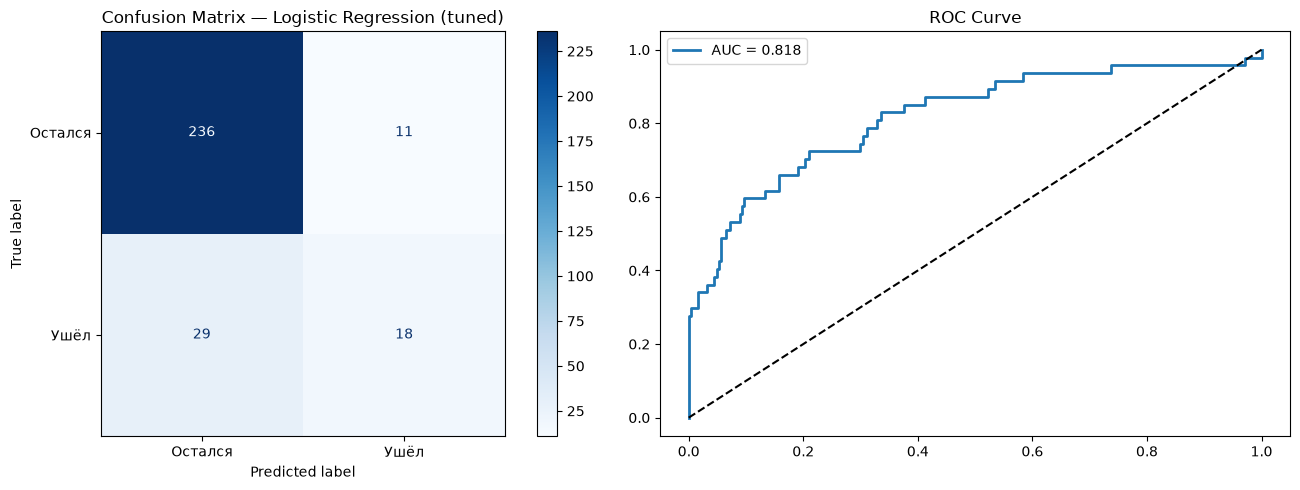

In [171]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Остался', 'Ушёл'],
    cmap='Blues', ax=ax[0]
)


ax[0].set_title('Confusion Matrix — Logistic Regression (tuned)')

fpr, tpr, _ = roc_curve(y_test, y_proba_final)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba_final):.3f}', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('ROC Curve')
ax[1].legend()
plt.tight_layout()
plt.show()


In [172]:
# Получаем имена признаков после OneHotEncoder

all_feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

all_feature_names

array(['num__Age', 'num__DistanceFromHome', 'num__MonthlyIncome',
       'num__NumCompaniesWorked', 'num__PercentSalaryHike',
       'num__TotalWorkingYears', 'num__TrainingTimesLastYear',
       'num__YearsAtCompany', 'num__YearsInCurrentRole',
       'num__YearsSinceLastPromotion', 'num__YearsWithCurrManager',
       'num__IsYoung', 'num__HighRisk', 'num__JobHopping',
       'num__BadWorkLife', 'num__FarFromHome', 'num__Education',
       'num__EnvironmentSatisfaction', 'num__JobInvolvement',
       'num__JobLevel', 'num__JobSatisfaction', 'num__PerformanceRating',
       'num__RelationshipSatisfaction', 'num__StockOptionLevel',
       'num__WorkLifeBalance', 'cat__BusinessTravel_Non-Travel',
       'cat__BusinessTravel_Travel_Frequently',
       'cat__BusinessTravel_Travel_Rarely',
       'cat__Department_Human Resources',
       'cat__Department_Research & Development', 'cat__Department_Sales',
       'cat__EducationField_Human Resources',
       'cat__EducationField_Life Sciences'

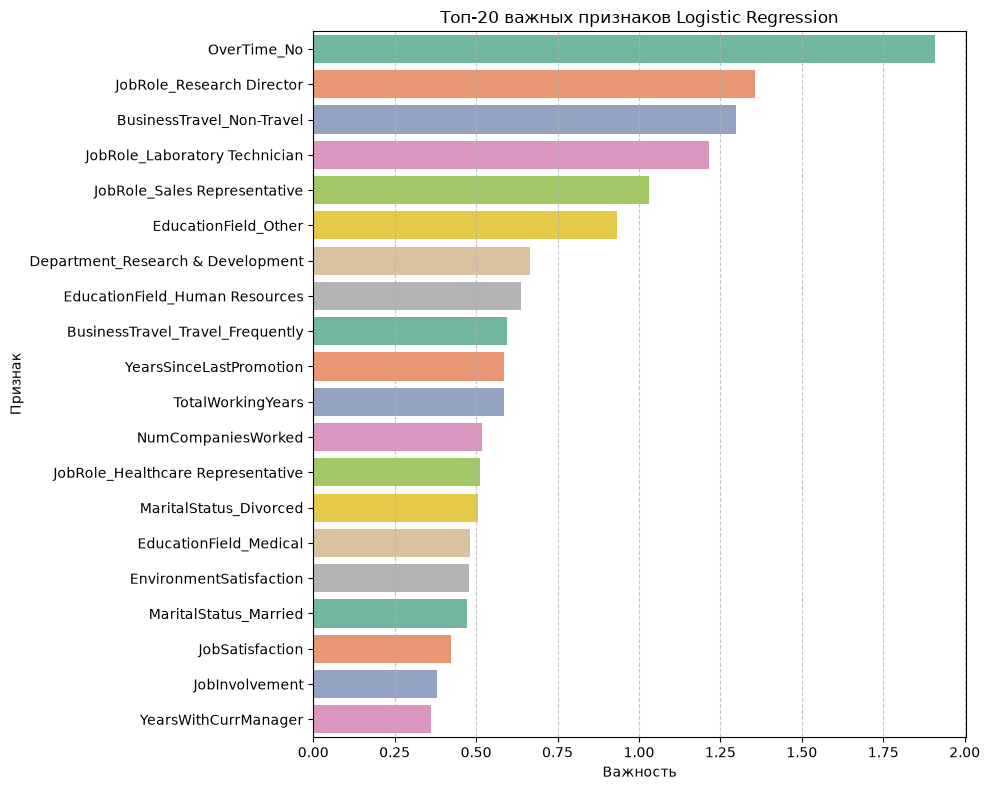


Топ-15 самых важных признаков:
OverTime_No                          1.9079
JobRole_Research Director            1.3566
BusinessTravel_Non-Travel            1.2993
JobRole_Laboratory Technician        1.2161
JobRole_Sales Representative         1.0322
EducationField_Other                 0.9340
Department_Research & Development    0.6646
EducationField_Human Resources       0.6387
BusinessTravel_Travel_Frequently     0.5963
YearsSinceLastPromotion              0.5859
TotalWorkingYears                    0.5842
NumCompaniesWorked                   0.5185
JobRole_Healthcare Representative    0.5105
MaritalStatus_Divorced               0.5058
EducationField_Medical               0.4818
dtype: float64


In [180]:
model = best_pipeline.named_steps['model']


if hasattr(model, 'coef_'):
    importances = pd.Series(abs(model.coef_[0]), index=all_feature_names).sort_values(ascending=False)

    importances.index = (
        importances.index
        .str.replace('num__', '', regex=False)
        .str.replace('cat__', '', regex=False)
    )

    plt.figure(figsize=(10, 8))
    sns.barplot(x=importances.head(20).values, y=importances.head(20).index, hue=importances.head(20).index, legend=False, palette='Set2')
    plt.title('Топ-20 важных признаков Logistic Regression')
    plt.xlabel('Важность')
    plt.ylabel('Признак')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('img/top20_features.png', format='png', dpi=200, bbox_inches='tight')
    plt.show()
    

    
    print("\nТоп-15 самых важных признаков:")
    print(importances.head(15).round(4))
    


## Итог проекта
Цель — заранее находить сотрудников с высоким риском увольнения, чтобы HR успевал вмешаться, а не оформлял уход.

Данные IBM HR `1470 сотрудников x 31 признак` без пропусков, отток `16.1%`, поэтому accuracy не подходит и мы меряем качество по `PR-AUC` и `F1`.

Анализ показал понятные тригеры: чаще уходят при переработках `30.5% против 10.4% без них`, частых командировках `24.9% против 8.0%`, в продажах `20.6%` и на стартовых ролях `Sales Representative 39.8%`, а дольше держатся при высоком грейде, доходе и стаже — все топ-корреляции отрицательные.

Для модели убрали шумовые ставки, добавили 5 флагов и собрали все в `Pipeline`: `StandardScaler` для чисел и шкал, `OneHotEncoder` для категорий, обучение строго внутри `train 1176 / test 294` со `stratify`.

Сравнили 4 модели, лучшей стала `Logistic Regression` с `PR-AUC 0.61, ROC-AUC 0.82`, после тюнинга `C/penalty/solver` по `GridSearchCV 5-fold` она дает `precision 0.62 при recall 0.38`: из 10 помеченных реально уйдут 6, а поймаем почти 4 из 10 уходящих.

Важные коэффтцтенты модели совпадают с аналитикой — переработки, роль, командировки, срок с последнего повышения, стаж и число смен компаний.

Ограничение: данных всего 1470 и это точечная оценка, редкие срезы шумят, порог 0.5 можно двигать под бюджет HR.


## Демо: как модель оценивает сотрудников
Возьмем двух людей из теста: одного с высоким риском, второго с низким. Посмотрим их риск и данные.


In [181]:
# Демо: высокий vs низкий риск (2 строки из теста)
proba = best_pipeline.predict_proba(X_test)[:, 1]

high_n = int(proba.argmax())  # самый рисковый
low_n = int(proba.argmin())  # самый спокойный

print(f"Сотрудник 1 (высокий риск, строка {X_test.index[high_n]}): риск {proba[high_n]:.1%}")
print(f"Сотрудник 2 (низкий риск, строка {X_test.index[low_n]}): риск {proba[low_n]:.1%}")

# Ключевые поля для проверки глазами
cols = ['Age', 'OverTime', 'JobRole', 'BusinessTravel', 'MonthlyIncome', 'JobSatisfaction', 'YearsAtCompany']
display(X_test.iloc[[high_n, low_n]][cols].T)

Сотрудник 1 (высокий риск, строка 357): риск 97.8%
Сотрудник 2 (низкий риск, строка 1111): риск 0.0%


,357,1111
Age,21,53
OverTime,Yes,No
JobRole,Sales Representative,Manufacturing Director
BusinessTravel,Travel_Frequently,Travel_Rarely
MonthlyIncome,2174,10169
JobSatisfaction,2,4
YearsAtCompany,3,33
